In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
  
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Yeo-Johnson Transform for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

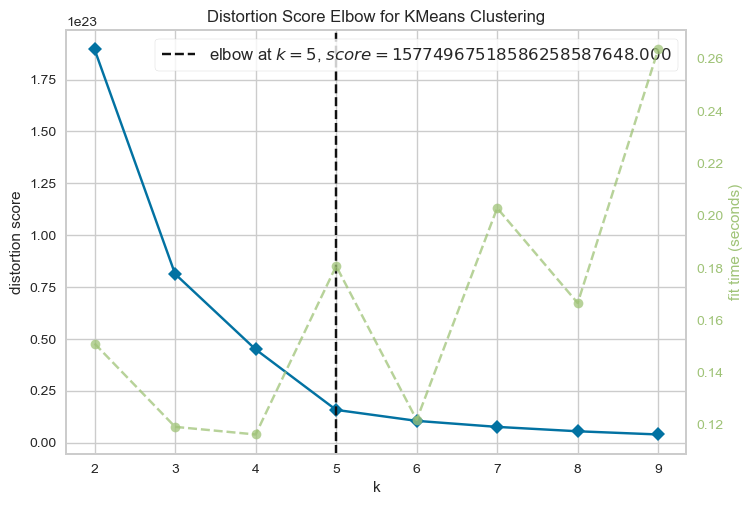

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glszm_GrayLevelNonUniformity_PET_c04
Correlation coefficient: 1.0072463768115951


1
Most correlated column: LBP_102_PET
Correlation coefficient: 1.0072463768115956


2
Most correlated column: glcm_DifferenceAverage_d_1_PET_c04
Correlation coefficient: 1.0072463768115951


3
Most correlated column: glrlm_RunLengthNonUniformityNormalized_CT_b20
Correlation coefficient: 1.007246376811595


4
Most correlated column: first_order_RobustMeanAbsoluteDeviation_PET
Correlation coefficient: 1.0072463768115951




In [21]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = pt.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
pt = PowerTransformer(method='yeo-johnson')
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.fit_transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,glcm_DifferenceAverage_d_1_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,first_order_RobustMeanAbsoluteDeviation_PET
0,1.545455,0.000000,0.356587,0.572390,2.608982
1,2.166667,0.000000,0.420129,0.551239,0.978390
2,6.777778,0.000034,0.325835,0.504802,1.184765
3,2.090909,0.000000,0.401664,0.667469,0.421149
4,4.333333,0.000199,0.510112,0.675873,0.914508
...,...,...,...,...,...
134,4.000000,0.000000,0.409956,0.482848,1.571160
135,4.000000,0.000000,0.321183,0.377902,0.941343
136,2.428571,0.000000,0.374487,0.446948,2.262096
137,6.333333,0.000000,0.402135,0.343403,1.167062


In [25]:
X_new_std

,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,glcm_DifferenceAverage_d_1_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,first_order_RobustMeanAbsoluteDeviation_PET
0,-1.814187,-0.784694,-0.094031,1.138066,0.929474
1,-1.216065,-0.784694,0.595643,0.960267,-0.726455
2,0.613776,0.236612,-0.468257,0.542538,-0.444272
3,-1.278916,-0.784694,0.405940,1.853525,-1.693580
4,-0.046796,1.784568,1.412495,1.910822,-0.820591
...,...,...,...,...,...
134,-0.174107,-0.784694,0.492151,0.330872,0.011153
135,-0.174107,-0.784694,-0.527421,-0.828713,-0.780622
136,-1.015564,-0.784694,0.111075,-0.036790,0.659936
137,0.519526,-0.784694,0.410886,-1.272208,-0.467274


In [26]:
MAASTRO_new

,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,glcm_DifferenceAverage_d_1_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,first_order_RobustMeanAbsoluteDeviation_PET
0,7.437500,0.000026,0.335443,0.351568,2.804536
1,6.111111,0.000167,0.279434,0.431179,1.112878
2,2.750000,0.000057,0.310763,0.378652,2.210455
3,3.000000,0.000000,0.301684,0.636279,1.225669
4,8.428571,0.000000,0.300615,0.342347,1.428017
...,...,...,...,...,...
94,3.842105,0.000000,0.327473,0.502355,7.089688
95,1.727273,0.000000,0.310449,0.553299,2.165934
96,9.666667,0.000000,0.264803,0.386943,1.052365
97,5.352941,0.000000,0.305581,0.552452,2.313589


In [27]:
MAASTRO_new_std

,glszm_GrayLevelNonUniformity_PET_c04,LBP_102_PET,glcm_DifferenceAverage_d_1_PET_c04,glrlm_RunLengthNonUniformityNormalized_CT_b20,first_order_RobustMeanAbsoluteDeviation_PET
0,1.038693,0.137798,0.242890,-1.698137,0.967980
1,0.742124,1.893161,-0.509102,-0.656416,-0.417263
2,-0.568181,0.848878,-0.074864,-1.326528,0.581104
3,-0.420163,-0.752601,-0.197019,1.449575,-0.289568
4,1.220594,-0.752601,-0.211593,-1.829029,-0.078220
...,...,...,...,...,...
94,-0.003920,-0.752601,0.142492,0.157590,2.567918
95,-1.357763,-0.752601,-0.079045,0.682525,0.548824
96,1.413340,-0.752601,-0.724708,-1.216459,-0.489065
97,0.535127,-0.752601,-0.144228,0.674148,0.653936


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:19:19,974] A new study created in memory with name: no-name-1f628201-1213-4233-8a78-5d38d8cb9200
python(7350) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5497835497835498
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6274509803921569
Fold 4 C-index: 0.6371308016877637


[I 2024-04-18 03:19:20,597] A new study created in memory with name: no-name-0baf36c8-3e57-4b78-8bc5-93a11d793abc


Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:20,586] Trial 0 finished with value: 0.6397258497395619 and parameters: {}. Best is trial 0 with value: 0.6397258497395619.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6397258497395619], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 20, 140651), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 20, 586118), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6397258497395619


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22653801799750425
Fold 2 IBS: 0.1928619059818947
Fold 3 IBS: 0.20785000024452346
Fold 4 IBS: 0.2159692705202995
Fold 5 IBS: 0.19504663689541038
[I 2024-04-18 03:19:21,389] Trial 0 finished with value: 0.20765316632792646 and parameters: {}. Best is trial 0 with value: 0.20765316632792646.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20765316632792646], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 20, 659477), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 21, 389388), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20765316632792646


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.64
train_ibs:  0.208


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.564
IBS score: 0.233


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:21,756] A new study created in memory with name: no-name-79c1963b-2a3a-44b6-a1c9-6e05d298d2e0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5995670995670995
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5808823529411765
Fold 4 C-index: 0.5949367088607594


[I 2024-04-18 03:19:22,148] A new study created in memory with name: no-name-8be4af24-be8e-4aff-8d15-e7ab0ccc9dc9


Fold 5 C-index: 0.5985915492957746
[I 2024-04-18 03:19:22,143] Trial 0 finished with value: 0.6292598278472478 and parameters: {}. Best is trial 0 with value: 0.6292598278472478.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6292598278472478], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 21, 837220), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 22, 142981), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6292598278472478


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651867085024
Fold 2 IBS: 0.2215779044043864
Fold 3 IBS: 0.20453594562699706
Fold 4 IBS: 0.22473803684925564
Fold 5 IBS: 0.21812431265940171
[I 2024-04-18 03:19:22,490] Trial 0 finished with value: 0.21659054364217822 and parameters: {}. Best is trial 0 with value: 0.21659054364217822.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054364217822], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 22, 192636), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 22, 490412), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054364217822


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.629
train_ibs:  0.217


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.544


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:22,737] A new study created in memory with name: no-name-e6b624c7-b74c-4ae9-b7c0-f5baf41f4802


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642


[I 2024-04-18 03:19:23,312] A new study created in memory with name: no-name-04125648-5b2e-4d29-b73e-fb934c0d1d0e


Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:23,276] Trial 0 finished with value: 0.6433963167756284 and parameters: {}. Best is trial 0 with value: 0.6433963167756284.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6433963167756284], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 22, 805933), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 23, 276088), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6433963167756284


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22552949762380237
Fold 2 IBS: 0.19247995138898832
Fold 3 IBS: 0.20734195741627742
Fold 4 IBS: 0.21552285970808466
Fold 5 IBS: 0.1955913886654484
[I 2024-04-18 03:19:23,979] Trial 0 finished with value: 0.20729313096052024 and parameters: {}. Best is trial 0 with value: 0.20729313096052024.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20729313096052024], datetime_start=datetime.datetime(2024, 4, 18, 3, 19, 23, 376775), datetime_complete=datetime.datetime(2024, 4, 18, 3, 19, 23, 979641), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20729313096052024


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.643
train_ibs:  0.207


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.564


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.233


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:19:24,597] A new study created in memory with name: no-name-6c3c775d-4912-479f-80af-effd02c03873


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:25,440] Trial 0 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6433963167756284.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:26,167] Trial 1 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6433963167756284.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:26,708] Trial 2 finished with value: 0.6442621176414292 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:38,062] Trial 24 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.5910098988284204}. Best is trial 2 with value: 0.6442621176414292.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:38,522] Trial 25 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.38971525832834536}. Best is trial 2 with value: 0.6442621176414292.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:38,997] Trial 26 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.7685574200470692

Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:53,702] Trial 47 finished with value: 0.6442621176414292 and parameters: {'l1_ratio': 0.23971145636476637}. Best is trial 2 with value: 0.6442621176414292.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6431924882629108
[I 2024-04-18 03:19:54,646] Trial 48 finished with value: 0.6433963167756284 and parameters: {'l1_ratio': 0.45102719011761083}. Best is trial 2 with value: 0.6442621176414292.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6384976525821596
[I 2024-04-18 03:19:55,913] Trial 49 finished with value: 0.643323150505279 and parameters: {'l1_ratio': 0.18927739469840132}. Best is trial 2 with value: 0.6442621176414292.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.

...

Fold 1 IBS: 0.22546415821154947
Fold 2 IBS: 0.1924523219892391
Fold 3 IBS: 0.20735133955612578
Fold 4 IBS: 0.21551899061534255
Fold 5 IBS: 0.19557675637271743
[I 2024-04-18 03:21:12,513] Trial 0 finished with value: 0.20727271334899483 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.20727271334899483.
Fold 1 IBS: 0.22540599582629453
Fold 2 IBS: 0.19237993952369375
Fold 3 IBS: 0.20734498124524237
Fold 4 IBS: 0.21551635032626973
Fold 5 IBS: 0.1955697025352539
[I 2024-04-18 03:21:13,794] Trial 1 finished with value: 0.20724339389135085 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.20724339389135085.
Fold 1 IBS: 0.22532435587803307
Fold 2 IBS: 0.1923866245899396
Fold 3 IBS: 0.20738143548410917
Fold 4 IBS: 0.21553922043437485
Fold 5 IBS: 0.19557260576248087
[I 2024-04-18 03:21:15,037] Trial 2 finished with value: 0.20724084842978754 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.207240848429

Fold 1 IBS: 0.22529121541549357
Fold 2 IBS: 0.1923185572313852
Fold 3 IBS: 0.20738463099362953
Fold 4 IBS: 0.21553846662164894
Fold 5 IBS: 0.19550151586948655
[I 2024-04-18 03:21:51,701] Trial 25 finished with value: 0.20720687722632877 and parameters: {'l1_ratio': 0.07099604584399499}. Best is trial 25 with value: 0.20720687722632877.
Fold 1 IBS: 0.2252344720889707
Fold 2 IBS: 0.19233804760873366
Fold 3 IBS: 0.2073913008135116
Fold 4 IBS: 0.21553270759786253
Fold 5 IBS: 0.19548757259314078
[I 2024-04-18 03:21:55,016] Trial 26 finished with value: 0.20719682014044388 and parameters: {'l1_ratio': 0.040669332602076474}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.21347344030756563
Fold 2 IBS: 0.21966513223917009
Fold 3 IBS: 0.2042869623249886
Fold 4 IBS: 0.22404210267825958
Fold 5 IBS: 0.21773315362894496
[I 2024-04-18 03:21:56,619] Trial 27 finished with value: 0.21584015823578576 and parameters: {'l1_ratio': 0.016560941611969082}. Best is trial 26 with value: 0.2071

Fold 5 IBS: 0.19555045050952477
[I 2024-04-18 03:22:43,010] Trial 49 finished with value: 0.20723753987972054 and parameters: {'l1_ratio': 0.20374214183530495}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.2253206078524321
Fold 2 IBS: 0.19232768773280137
Fold 3 IBS: 0.20742236931456814
Fold 4 IBS: 0.21556138390993615
Fold 5 IBS: 0.1954956873828203
[I 2024-04-18 03:22:45,297] Trial 50 finished with value: 0.2072255472385116 and parameters: {'l1_ratio': 0.0397630144860471}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.22536095329263414
Fold 2 IBS: 0.19235497613706673
Fold 3 IBS: 0.20738709263894642
Fold 4 IBS: 0.21553146132060208
Fold 5 IBS: 0.19555902183373647
[I 2024-04-18 03:22:47,191] Trial 51 finished with value: 0.20723870104459716 and parameters: {'l1_ratio': 0.16407339741487448}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.2252977388037515
Fold 2 IBS: 0.1923188886488786
Fold 3 IBS: 0.20740734427228374
Fold 4 IBS: 0.2155504

Fold 1 IBS: 0.2252774203398008
Fold 2 IBS: 0.1923600123021298
Fold 3 IBS: 0.2074002803869406
Fold 4 IBS: 0.2155609297326419
Fold 5 IBS: 0.1955331491439959
[I 2024-04-18 03:23:32,076] Trial 74 finished with value: 0.20722635838110176 and parameters: {'l1_ratio': 0.096176051917815}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.22529751765624553
Fold 2 IBS: 0.1923199078598833
Fold 3 IBS: 0.20739791552342757
Fold 4 IBS: 0.21554589202473015
Fold 5 IBS: 0.19552729059400353
[I 2024-04-18 03:23:34,462] Trial 75 finished with value: 0.207217704731658 and parameters: {'l1_ratio': 0.058148325873444866}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.22536737064783685
Fold 2 IBS: 0.1923590111627284
Fold 3 IBS: 0.20737716725891037
Fold 4 IBS: 0.2155272481227417
Fold 5 IBS: 0.19557336937782888
[I 2024-04-18 03:23:36,930] Trial 76 finished with value: 0.20724083331400928 and parameters: {'l1_ratio': 0.1861827146441441}. Best is trial 26 with value: 0.20719682014044

Fold 5 IBS: 0.19559736634003078
[I 2024-04-18 03:24:23,577] Trial 98 finished with value: 0.20727399064617175 and parameters: {'l1_ratio': 0.4207653949718071}. Best is trial 26 with value: 0.20719682014044388.
Fold 1 IBS: 0.2135015433481164
Fold 2 IBS: 0.2197695761673681
Fold 3 IBS: 0.20430028015413904
Fold 4 IBS: 0.22408089976562534
Fold 5 IBS: 0.21775462058588055
[I 2024-04-18 03:24:25,073] Trial 99 finished with value: 0.21588138400422588 and parameters: {'l1_ratio': 0.015565764342779651}. Best is trial 26 with value: 0.20719682014044388.


* Best trial for IBS: 
 FrozenTrial(number=26, state=TrialState.COMPLETE, values=[0.20719682014044388], datetime_start=datetime.datetime(2024, 4, 18, 3, 21, 51, 707642), datetime_complete=datetime.datetime(2024, 4, 18, 3, 21, 55, 7550), params={'l1_ratio': 0.040669332602076474}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=26, value=None

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.644
train_ibs:  0.207


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.22692876841884668)

test_cindex : 0.564


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.040669332602076474)

test_ibs:  0.233


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 03:24:26,251] A new study created in memory with name: no-name-97560943-62be-4dea-ad72-a37be0a8b50c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7790178571428571
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.5569620253164557
Fold 5 C-index: 0.5539906103286385
[I 2024-04-18 03:24:41,620] Trial 0 finished with value: 0.6259059905871294 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6259059905871294.
Fold 1 C-index: 0.5541125541125541
Fold 2 C-index: 0.8125
Fold 3 C-index: 0.6421568627450981
Fold 4 C-index: 0.5949367088607594
Fold 5 C-index: 0.5868544600938967
[I 2024-04-18 03:24:55,087] Trial 1 finished with value: 0.6381121171624617 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_feature

Fold 3 C-index: 0.6838235294117647
Fold 4 C-index: 0.6518987341772152
Fold 5 C-index: 0.6244131455399061
[I 2024-04-18 03:27:22,500] Trial 15 finished with value: 0.6807175580162534 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 383, 'oob_score': True, 'max_samples': 0.817309431417591, 'max_features': None, 'min_weight_fraction_leaf': 0.17997908224103165, 'warm_start': True}. Best is trial 14 with value: 0.6811646702798528.
Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.8482142857142857
Fold 3 C-index: 0.6813725490196079
Fold 4 C-index: 0.6582278481012658
Fold 5 C-index: 0.6291079812206573
[I 2024-04-18 03:27:34,466] Trial 16 finished with value: 0.6828650522916828 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.8031281433915335, 'max_features': None, 'min_weight_fraction_leaf': 0.1937733174239513, '

Fold 1 C-index: 0.5909090909090909
Fold 2 C-index: 0.8482142857142857
Fold 3 C-index: 0.7107843137254902
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.6408450704225352
[I 2024-04-18 03:29:54,705] Trial 30 finished with value: 0.6923277673441538 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 9, 'n_estimators': 238, 'oob_score': True, 'max_samples': 0.8769866053560933, 'max_features': None, 'min_weight_fraction_leaf': 0.2486312042554125, 'warm_start': True}. Best is trial 27 with value: 0.7250701165407573.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.8482142857142857
Fold 3 C-index: 0.7450980392156863
Fold 4 C-index: 0.6919831223628692
Fold 5 C-index: 0.7065727699530516
[I 2024-04-18 03:30:02,805] Trial 31 finished with value: 0.7100619551374903 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 11, 'max_depth': 9, 'n_estimators': 347, 'oob_score': True, 'max_samples': 0.9703935421441319, 'm

...

Fold 1 IBS: 0.2140213566128481
Fold 2 IBS: 0.22150043753473514
Fold 3 IBS: 0.20479850992880297
Fold 4 IBS: 0.2247133509850981
Fold 5 IBS: 0.21885327549571335
[I 2024-04-18 03:40:34,615] Trial 32 finished with value: 0.21677738611143954 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 255, 'oob_score': False, 'max_samples': 0.6752379846937863, 'max_features': None, 'min_weight_fraction_leaf': 0.4439959658921005}. Best is trial 22 with value: 0.2028112604664795.
Fold 1 IBS: 0.20446527727616143
Fold 2 IBS: 0.17748621920329746
Fold 3 IBS: 0.1946181709621695
Fold 4 IBS: 0.22017002054366128
Fold 5 IBS: 0.23187210987387266
[I 2024-04-18 03:40:47,239] Trial 33 finished with value: 0.2057223595718325 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 9, 'max_depth': 13, 'n_estimators': 369, 'oob_score': False, 'max_samples': 0.9318913067260477, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.21401117618543283
Fold 2 IBS: 0.22140794144992493
Fold 3 IBS: 0.20483040438189826
Fold 4 IBS: 0.22470902871414294
Fold 5 IBS: 0.21874800118761417
[I 2024-04-18 03:43:29,214] Trial 48 finished with value: 0.21674131038380265 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 16, 'n_estimators': 267, 'oob_score': True, 'max_samples': 0.7091463590184712, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3788472900531026}. Best is trial 42 with value: 0.20210013582111505.
Fold 1 IBS: 0.21069049924773384
Fold 2 IBS: 0.18608852703826254
Fold 3 IBS: 0.1997413711958461
Fold 4 IBS: 0.21919651169490667
Fold 5 IBS: 0.23116329833903157
[I 2024-04-18 03:43:35,181] Trial 49 finished with value: 0.2093760415031561 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 13, 'n_estimators': 127, 'oob_score': True, 'max_samples': 0.9938559132339422, 'max_features': None, 'min_weight_fraction_leaf

Fold 1 IBS: 0.21399284658902498
Fold 2 IBS: 0.22046435044782026
Fold 3 IBS: 0.2054616886545281
Fold 4 IBS: 0.22501436322283086
Fold 5 IBS: 0.21727126151549997
[I 2024-04-18 03:47:36,307] Trial 64 finished with value: 0.21644090208594086 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 13, 'max_depth': 20, 'n_estimators': 305, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': None, 'min_weight_fraction_leaf': 0.20813653170824842}. Best is trial 42 with value: 0.20210013582111505.
Fold 1 IBS: 0.20862667254414013
Fold 2 IBS: 0.1827696950404169
Fold 3 IBS: 0.19414427166211615
Fold 4 IBS: 0.22041706637506167
Fold 5 IBS: 0.2284646211578077
[I 2024-04-18 03:47:50,525] Trial 65 finished with value: 0.2068844653559085 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 10, 'min_samples_leaf': 17, 'max_depth': 8, 'n_estimators': 279, 'oob_score': True, 'max_samples': 0.7308782800137212, 'max_features': None, 'min_weight_fraction_leaf

Fold 1 IBS: 0.20614072987963636
Fold 2 IBS: 0.17897694757710386
Fold 3 IBS: 0.1917688994071578
Fold 4 IBS: 0.2158098681603592
Fold 5 IBS: 0.2225144444834461
[I 2024-04-18 03:51:23,557] Trial 80 finished with value: 0.20304217790154064 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 7, 'min_samples_leaf': 18, 'max_depth': 18, 'n_estimators': 338, 'oob_score': True, 'max_samples': 0.5086024211087247, 'max_features': None, 'min_weight_fraction_leaf': 0.08886127488578334}. Best is trial 76 with value: 0.2016939836380453.
Fold 1 IBS: 0.20559439111706082
Fold 2 IBS: 0.17813714730160268
Fold 3 IBS: 0.19236957025170062
Fold 4 IBS: 0.2160241412623532
Fold 5 IBS: 0.22585261827921826
[I 2024-04-18 03:51:41,262] Trial 81 finished with value: 0.20359557364238712 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 20, 'max_depth': 17, 'n_estimators': 384, 'oob_score': True, 'max_samples': 0.5730174602251539, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.20807284930303457
Fold 2 IBS: 0.19715671283817734
Fold 3 IBS: 0.19300336359002968
Fold 4 IBS: 0.21764598702113835
Fold 5 IBS: 0.21136817367073318
[I 2024-04-18 03:56:39,333] Trial 96 finished with value: 0.20544941728462263 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 20, 'max_depth': 20, 'n_estimators': 468, 'oob_score': True, 'max_samples': 0.48927225300461336, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.18607083055406023}. Best is trial 76 with value: 0.2016939836380453.
Fold 1 IBS: 0.2054658695459997
Fold 2 IBS: 0.17990489135562784
Fold 3 IBS: 0.19476108815876894
Fold 4 IBS: 0.21651539351963717
Fold 5 IBS: 0.22585667222357494
[I 2024-04-18 03:57:03,095] Trial 97 finished with value: 0.20450078296072172 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 477, 'oob_score': True, 'max_samples': 0.5597527669973281, 'max_features': None, 'min_weight_fraction_le

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.79
train_ibs:  0.202


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_features='auto', max_leaf_nodes=9,
                     max_samples=0.7112910768016573, min_samples_leaf=2,
                     min_samples_split=9,
                     min_weight_fraction_leaf=0.015421682850990059,
                     n_estimators=213, random_state=123, warm_start=True)

test_cindex:  0.557


RandomSurvivalForest(max_depth=18, max_features=None, max_leaf_nodes=6,
                     max_samples=0.499406346297245, min_samples_leaf=19,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.06293202163557084,
                     n_estimators=292, oob_score=True, random_state=123)

test_ibs:  0.225


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 03:57:44,935] A new study created in memory with name: no-name-01c2a791-1ece-4660-bcb3-6e52d64494d2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.6617647058823529
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6572769953051644
[I 2024-04-18 03:57:47,338] Trial 0 finished with value: 0.6750870404402544 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6750870404402544.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 03:57:54,739] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5432900432900433
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.6200980392156863
Fold 4 C-index: 0.569620253164557
Fold 5 C-index: 0.6596244131455399
[I 2024-04-18 03:59:20,823] Trial 16 finished with value: 0.645490835477451 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 16, 'n_estimators': 178, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.5922140217118563, 'min_weight_fraction_leaf': 0.23841142158742942}. Best is trial 6 with value: 0.6768624801903775.
Fold 1 C-index: 0.5714285714285714
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.6568627450980392
Fold 4 C-index: 0.6244725738396625
Fold 5 C-index: 0.6384976525821596
[I 2024-04-18 03:59:24,054] Trial 17 finished with value: 0.6661094514468293 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 7, 'max_depth': 10, 'n_estimators': 401, 'oob_score': False, 'warm_start': True, 'max_features'

Fold 1 C-index: 0.5887445887445888
Fold 2 C-index: 0.8482142857142857
Fold 3 C-index: 0.6862745098039216
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.6666666666666666
[I 2024-04-18 04:00:10,698] Trial 31 finished with value: 0.684562288666905 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 4, 'n_estimators': 33, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.880776844733878, 'min_weight_fraction_leaf': 0.07589392630375186}. Best is trial 30 with value: 0.7007031942098221.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7088607594936709
Fold 5 C-index: 0.7981220657276995
[I 2024-04-18 04:00:11,991] Trial 32 finished with value: 0.7289812352760031 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 8, 'n_estimators': 93, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.2075177577634884
Fold 2 IBS: 0.20570724091980394
Fold 3 IBS: 0.20352391665981515
Fold 4 IBS: 0.215754288064927
Fold 5 IBS: 0.21111662974176132
[I 2024-04-18 04:07:54,550] Trial 30 finished with value: 0.20872396662995918 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 13, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 275, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6119797846699515, 'min_weight_fraction_leaf': 0.03347611067336217}. Best is trial 25 with value: 0.20512531273177972.
Fold 1 IBS: 0.2078385930164827
Fold 2 IBS: 0.20547159281757696
Fold 3 IBS: 0.20279182505479995
Fold 4 IBS: 0.21531239001857536
Fold 5 IBS: 0.21175083217542773
[I 2024-04-18 04:08:04,012] Trial 31 finished with value: 0.20863304661657253 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 13, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 290, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.60

Fold 1 IBS: 0.20916598883075432
Fold 2 IBS: 0.2082752701549466
Fold 3 IBS: 0.20571163505784015
Fold 4 IBS: 0.21771045623221547
Fold 5 IBS: 0.21215451964766704
[I 2024-04-18 04:11:47,814] Trial 45 finished with value: 0.2106035739846847 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 434, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.4326670363191812, 'min_weight_fraction_leaf': 0.0031391814142599115}. Best is trial 25 with value: 0.20512531273177972.
Fold 1 IBS: 0.21397425250375926
Fold 2 IBS: 0.22144772584220293
Fold 3 IBS: 0.2049396171902743
Fold 4 IBS: 0.22466981503363515
Fold 5 IBS: 0.21830657391824176
[I 2024-04-18 04:12:05,889] Trial 46 finished with value: 0.2166675968976227 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 483, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.35466

Fold 1 IBS: 0.21180289861781468
Fold 2 IBS: 0.21772203137391224
Fold 3 IBS: 0.20292494188907215
Fold 4 IBS: 0.22329432790921583
Fold 5 IBS: 0.21629857529985283
[I 2024-04-18 04:15:56,058] Trial 60 finished with value: 0.2144085550179735 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 11, 'min_samples_leaf': 12, 'max_depth': 10, 'n_estimators': 190, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.5876523474241502, 'min_weight_fraction_leaf': 0.04725927619620414}. Best is trial 25 with value: 0.20512531273177972.
Fold 1 IBS: 0.2078537581517519
Fold 2 IBS: 0.19929110945428113
Fold 3 IBS: 0.20202422801725609
Fold 4 IBS: 0.21223306909573636
Fold 5 IBS: 0.2103537154374057
[I 2024-04-18 04:16:14,702] Trial 61 finished with value: 0.20635117603128625 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 473, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.3640325

Fold 1 IBS: 0.2074695103097141
Fold 2 IBS: 0.19744307795487254
Fold 3 IBS: 0.19892787830658124
Fold 4 IBS: 0.22225338937016598
Fold 5 IBS: 0.21022753681755188
[I 2024-04-18 04:19:50,979] Trial 75 finished with value: 0.20726427855177715 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 307, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.26466085085393315, 'min_weight_fraction_leaf': 0.04889410398458893}. Best is trial 65 with value: 0.20243848707656134.
Fold 1 IBS: 0.2071698321669402
Fold 2 IBS: 0.1973588656297029
Fold 3 IBS: 0.20216903571205574
Fold 4 IBS: 0.22034336307261718
Fold 5 IBS: 0.20901047870647188
[I 2024-04-18 04:20:04,079] Trial 76 finished with value: 0.20721031505755758 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 13, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 328, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.22

Fold 1 IBS: 0.20936044911976
Fold 2 IBS: 0.19321001636798674
Fold 3 IBS: 0.1999701342958763
Fold 4 IBS: 0.218274153329974
Fold 5 IBS: 0.20575324420943655
[I 2024-04-18 04:23:28,708] Trial 90 finished with value: 0.20531359946460676 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 6, 'n_estimators': 343, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.24453563711596438, 'min_weight_fraction_leaf': 0.014812081368883566}. Best is trial 65 with value: 0.20243848707656134.
Fold 1 IBS: 0.21153097042197988
Fold 2 IBS: 0.20158455078321114
Fold 3 IBS: 0.202873282323098
Fold 4 IBS: 0.21832390092956844
Fold 5 IBS: 0.20714747346922213
[I 2024-04-18 04:23:43,524] Trial 91 finished with value: 0.20829203558541592 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 6, 'n_estimators': 372, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.1060909

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.754
train_ibs:  0.202


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features='auto', max_leaf_nodes=10,
                   max_samples=0.96592287514128, min_samples_leaf=2,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.0411958561698762, n_estimators=40,
                   oob_score=True, random_state=123, warm_start=True)

C-index score: 0.579


ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=8,
                   max_samples=0.31794308872117644, min_samples_leaf=1,
                   min_samples_split=7,
                   min_weight_fraction_leaf=0.021138682438818397,
                   n_estimators=394, oob_score=True, random_state=123)

IBS: 0.219


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-18 04:25:48,284] A new study created in memory with name: no-name-53515cbe-22b8-4ca7-8c13-a8244a66fa44


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:26:52,580] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:27:26,103] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:45:38,629] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6268170094826047.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 04:47:57,693] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-18 05:12:52,352] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.642639580204438.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-18 05:15:50,942] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-18 07:21:44,732] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21542484912237173.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:21:53,201] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20404087693135828
Fold 4 IBS: 0.22436400029839254
Fold 5 IBS: 0.21769172272034362
[I 2024-04-18 07:25:09,759] Trial 55 finished with value: 0.21607392723091418 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21542484912237173.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-18 07:25:24,654] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.0637477868768

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-18 07:27:00,260] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 42 with value: 0.21542484912237173.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:27:07,486] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-18 07:28:55,429] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5357913465602108, 'learning_rate': 0.0688819536532142, 'dropout_rate': 0.6862373753371346, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09391314070620446, 'max_features': None, 'min_impurity_decrease': 0.0012137274295836362, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 72 with value: 0.21496287867829808.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-18 07:29:00,133] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.4666635842806658, 'learning_rate': 0.07574965743659788, 'dropout_rate': 0.7638959024

Fold 5 IBS: 0.21812431525609574
[I 2024-04-18 07:31:08,860] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5070937054239855, 'learning_rate': 0.09973607041445856, 'dropout_rate': 0.9567720388343455, 'n_estimators': 134, 'criterion': 'friedman_mse', 'ccp_alpha': 1.9600784886531912, 'min_weight_fraction_leaf': 0.16122733058332964, 'max_features': 0.1, 'min_impurity_decrease': 0.00012035323982044348, 'validation_fraction': 0.38803363853798506, 'min_samples_split': 19, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 5}. Best is trial 72 with value: 0.21496287867829808.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-18 07:31:11,695] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.042896534476020334, 'dropout_rate': 0.9006714701688298, 'n_estimators': 83, 

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.645
train_ibs:  0.215


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03768433016684238,
                                 dropout_rate=0.8518170622435416,
                                 learning_rate=0.07516712250657744,
                                 max_depth=17, max_features='sqrt',
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=0.0033194018014140463,
                                 min_samples_leaf=19, min_samples_split=9,
                                 min_weight_fraction_leaf=0.09954476156869702,
                                 n_estimators=133, random_state=123,
                                 subsample=0.6366017902680755,
                                 validation_fraction=0.242274730848875)

C-index score: 0.556


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004871747166097406,
                                 dropout_rate=0.6189253137574503,
                                 learning_rate=0.06881913799343405, max_depth=7,
                                 max_leaf_nodes=18,
                                 min_impurity_decrease=0.0002660011363636655,
                                 min_samples_leaf=6, min_samples_split=20,
                                 min_weight_fraction_leaf=0.06846908431880266,
                                 n_estimators=158, random_state=123,
                                 subsample=0.5902124896086359,
                                 validation_fraction=0.30076951404539404)

IBS: 0.22


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-18 07:33:17,088] A new study created in memory with name: no-name-934e742a-6107-4f53-9b7b-2dd12d8f03ed


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.6455696202531646
Fold 5 C-index: 0.6103286384976526
[I 2024-04-18 07:33:19,257] Trial 0 finished with value: 0.6280178870442811 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6280178870442811.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 4 C-index: 0.6413502109704642
Fold 5 C-index: 0.6056338028169014
[I 2024-04-18 07:33:37,242] Trial 1 finished with value: 0.6262350380515909 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6280178870442811.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.5196078431372549
Fold 

Fold 1 C-index: 0.5757575757575758
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5735294117647058
Fold 4 C-index: 0.6033755274261603
Fold 5 C-index: 0.6103286384976526
[I 2024-04-18 07:36:17,607] Trial 19 finished with value: 0.6270625164035046 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.6351449762793008.
Fold 1 C-index: 0.6017316017316018
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5686274509803921
Fold 4 C-index: 0.6118143459915611
Fold 5 C-index: 0.6150234741784038
[I 2024-04-18 07:36:36,459] Trial 20 finished with value: 0.6339036602906776 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.6351449762793008.
Fold 1 C-index: 0.5930735930735931
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.5637254901960784

Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.5441176470588235
Fold 4 C-index: 0.6286919831223629
Fold 5 C-index: 0.6150234741784038
[I 2024-04-18 07:40:45,107] Trial 38 finished with value: 0.630618568923866 and parameters: {'subsample': 0.23557094034920928, 'dropout_rate': 0.3825907490030003, 'n_estimators': 402, 'learning_rate': 0.07288612365177065}. Best is trial 32 with value: 0.638338024434883.
Fold 1 C-index: 0.5974025974025974
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.5490196078431373
Fold 4 C-index: 0.6329113924050633
Fold 5 C-index: 0.6009389671361502
[I 2024-04-18 07:41:02,883] Trial 39 finished with value: 0.6269473701002468 and parameters: {'subsample': 0.31743088110901685, 'dropout_rate': 0.2815909157786247, 'n_estimators': 456, 'learning_rate': 0.06892741183938003}. Best is trial 32 with value: 0.638338024434883.
Fold 1 C-index: 0.5887445887445888
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.5637254901960784
Fo

...

Fold 2 IBS: 0.17729858581142446
Fold 3 IBS: 0.27259330315625874
Fold 4 IBS: 0.2282090261630484
Fold 5 IBS: 0.23143039385121544
[I 2024-04-18 07:56:29,569] Trial 19 finished with value: 0.2241405538761078 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.9930703343219778, 'n_estimators': 132, 'learning_rate': 0.04269105711861253}. Best is trial 7 with value: 0.20876228426793922.
Fold 1 IBS: 0.21144219059438918
Fold 2 IBS: 0.21604282945001188
Fold 3 IBS: 0.20442362001393807
Fold 4 IBS: 0.22113367829935057
Fold 5 IBS: 0.21622468928587033
[I 2024-04-18 07:56:30,749] Trial 20 finished with value: 0.213853401528712 and parameters: {'subsample': 0.1970276176208972, 'dropout_rate': 0.5558690358940764, 'n_estimators': 52, 'learning_rate': 0.008488975765234177}. Best is trial 7 with value: 0.20876228426793922.
Fold 1 IBS: 0.20630316341946137
Fold 2 IBS: 0.1935570345831388
Fold 3 IBS: 0.21767903395542987
Fold 4 IBS: 0.21303907977382314
Fold 5 IBS: 0.21545800206322457
[I 2024-04

Fold 2 IBS: 0.1608909259399477
Fold 3 IBS: 0.2600898366249045
Fold 4 IBS: 0.2551730856837355
Fold 5 IBS: 0.23648071429099363
[I 2024-04-18 07:57:18,805] Trial 38 finished with value: 0.22768139310124136 and parameters: {'subsample': 0.15497420924668578, 'dropout_rate': 0.2987316040511009, 'n_estimators': 182, 'learning_rate': 0.04794930862279789}. Best is trial 24 with value: 0.20819118342209197.
Fold 1 IBS: 0.24873813674363165
Fold 2 IBS: 0.19459391877208165
Fold 3 IBS: 0.3515193672834441
Fold 4 IBS: 0.25534534395939557
Fold 5 IBS: 0.29064258595433645
[I 2024-04-18 07:57:25,712] Trial 39 finished with value: 0.2681678705425779 and parameters: {'subsample': 0.46050437175715375, 'dropout_rate': 0.419178760171001, 'n_estimators': 272, 'learning_rate': 0.05598015324329953}. Best is trial 24 with value: 0.20819118342209197.
Fold 1 IBS: 0.24620049750635084
Fold 2 IBS: 0.17134584633973773
Fold 3 IBS: 0.2937097856413142
Fold 4 IBS: 0.2683878974110068
Fold 5 IBS: 0.2905768551518744
[I 2024-04-

Fold 2 IBS: 0.2088281944444014
Fold 3 IBS: 0.20783585712861002
Fold 4 IBS: 0.21817011488553748
Fold 5 IBS: 0.2151847495436007
[I 2024-04-18 07:58:05,795] Trial 57 finished with value: 0.21167438547734432 and parameters: {'subsample': 0.2647514174675062, 'dropout_rate': 0.4572889156809624, 'n_estimators': 74, 'learning_rate': 0.014562403757758453}. Best is trial 24 with value: 0.20819118342209197.
Fold 1 IBS: 0.21179287699974494
Fold 2 IBS: 0.21717009887952762
Fold 3 IBS: 0.20411819614211055
Fold 4 IBS: 0.22155116806704292
Fold 5 IBS: 0.21666754085086065
[I 2024-04-18 07:58:07,269] Trial 58 finished with value: 0.21425997618785733 and parameters: {'subsample': 0.22364972882361067, 'dropout_rate': 0.6279067956450026, 'n_estimators': 54, 'learning_rate': 0.006701284086793099}. Best is trial 24 with value: 0.20819118342209197.
Fold 1 IBS: 0.26610788350527803
Fold 2 IBS: 0.25017414214292827
Fold 3 IBS: 0.4001238850576193
Fold 4 IBS: 0.22833995089414927
Fold 5 IBS: 0.2947332672433912
[I 2024

Fold 3 IBS: 0.2161389898254834
Fold 4 IBS: 0.21321332693486295
Fold 5 IBS: 0.20929896821526986
[I 2024-04-18 07:58:50,048] Trial 76 finished with value: 0.20759049534902368 and parameters: {'subsample': 0.15020911413757723, 'dropout_rate': 0.8413092513472038, 'n_estimators': 47, 'learning_rate': 0.06470910055219464}. Best is trial 75 with value: 0.2059710491683448.
Fold 1 IBS: 0.20645120633102806
Fold 2 IBS: 0.19075746738887098
Fold 3 IBS: 0.2057968874417804
Fold 4 IBS: 0.21700808389227358
Fold 5 IBS: 0.20963520487365844
[I 2024-04-18 07:58:51,126] Trial 77 finished with value: 0.20592976998552232 and parameters: {'subsample': 0.10018043050021358, 'dropout_rate': 0.8417409493509668, 'n_estimators': 43, 'learning_rate': 0.0648382511881321}. Best is trial 77 with value: 0.20592976998552232.
Fold 1 IBS: 0.2087224586475866
Fold 2 IBS: 0.19112109360608767
Fold 3 IBS: 0.21148645346205758
Fold 4 IBS: 0.21281758302585416
Fold 5 IBS: 0.21061558631003055
[I 2024-04-18 07:58:52,303] Trial 78 fini

Fold 3 IBS: 0.21950733153385676
Fold 4 IBS: 0.2246147129692359
Fold 5 IBS: 0.21314557752293647
[I 2024-04-18 07:59:14,175] Trial 95 finished with value: 0.20945956346943148 and parameters: {'subsample': 0.10076504071457582, 'dropout_rate': 0.7394553030803492, 'n_estimators': 64, 'learning_rate': 0.06621944747496411}. Best is trial 81 with value: 0.20571658506832632.
Fold 1 IBS: 0.20611664462622895
Fold 2 IBS: 0.18804554285433492
Fold 3 IBS: 0.22014515812335433
Fold 4 IBS: 0.2172555478132423
Fold 5 IBS: 0.21452236158543125
[I 2024-04-18 07:59:15,380] Trial 96 finished with value: 0.20921705100051832 and parameters: {'subsample': 0.18284325354000547, 'dropout_rate': 0.8268000623124828, 'n_estimators': 53, 'learning_rate': 0.05807404263636947}. Best is trial 81 with value: 0.20571658506832632.
Fold 1 IBS: 0.20587425919521712
Fold 2 IBS: 0.18446036440005156
Fold 3 IBS: 0.23001106874567356
Fold 4 IBS: 0.21806993024819407
Fold 5 IBS: 0.20919737104881425
[I 2024-04-18 07:59:16,941] Trial 97 f

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.638
train_ibs:  0.206


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.41151300064689594,
                                              learning_rate=0.024043599287057932,
                                              n_estimators=445,
                                              random_state=123,
                                              subsample=0.10232015898333158)

C-index score: 0.549


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.836055996855701,
                                              learning_rate=0.06535515620761163,
                                              n_estimators=48, random_state=123,
                                              subsample=0.10937738812559525)

IBS: 0.224


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.790,1.0
ExtraSurvivalTrees,0.754,2.0
GradientBoosting,0.645,3.0
CoxElastic,0.644,4.0
CoxLasso,0.643,5.0
CoxPH,0.640,6.0
ComponentwiseGradientBoosting,0.638,7.0
CoxRidge,0.629,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.202,1.5
ExtraSurvivalTrees,0.202,1.5
ComponentwiseGradientBoosting,0.206,3.0
CoxLasso,0.207,4.5
CoxElastic,0.207,4.5
CoxPH,0.208,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.579,1.0
CoxPH,0.564,3.0
CoxLasso,0.564,3.0
CoxElastic,0.564,3.0
Randomsurvivalforest,0.557,5.0
GradientBoosting,0.556,6.0
ComponentwiseGradientBoosting,0.549,7.0
CoxRidge,0.544,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.219,1.0
GradientBoosting,0.220,2.0
CoxRidge,0.221,3.0
ComponentwiseGradientBoosting,0.224,4.0
Randomsurvivalforest,0.225,5.0
CoxPH,0.233,7.0
CoxLasso,0.233,7.0
CoxElastic,0.233,7.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/os/yeojohnson/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_os_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-18
